Using device: cuda


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.5952598391071199


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.6101504720392681
BERT Results: 0.7725
DistilBERT Results: 0.79


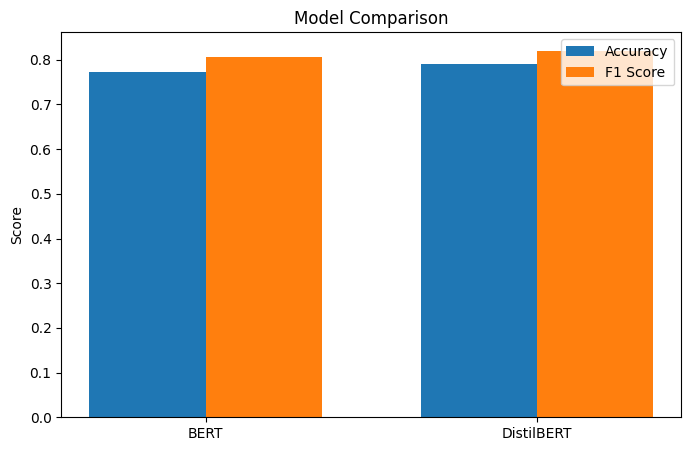

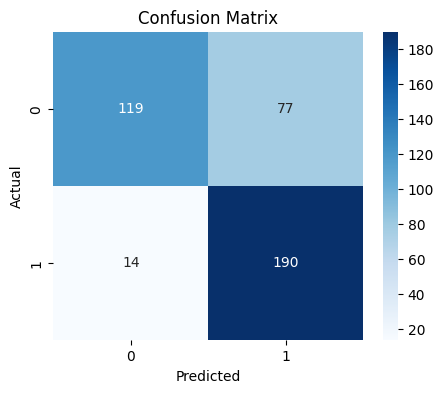

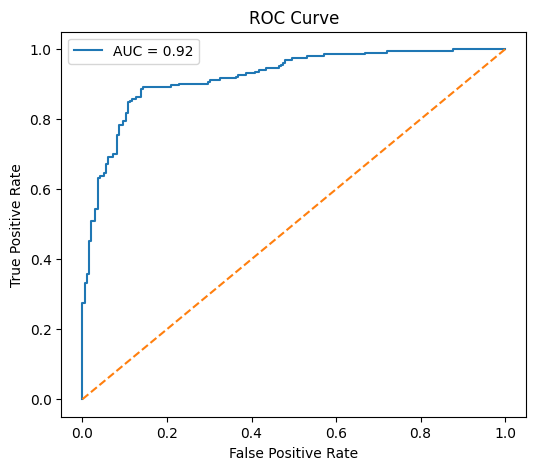

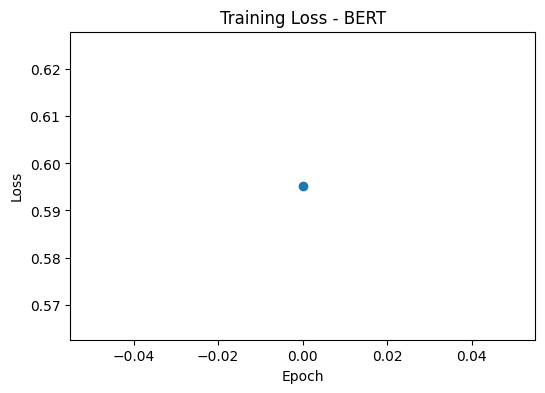

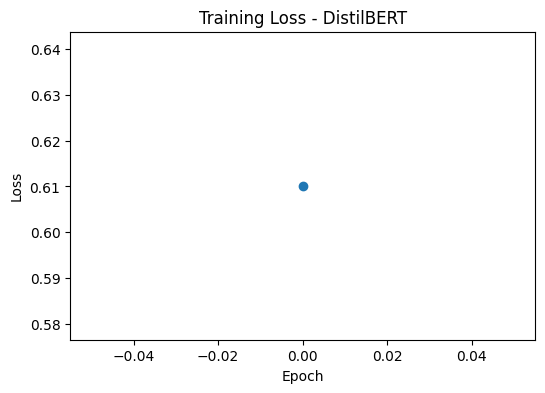

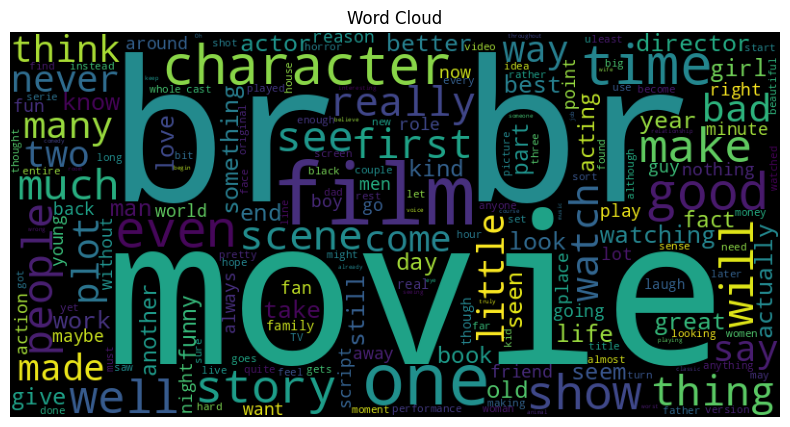

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9a51974bf6aae3f53d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:

# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install transformers datasets scikit-learn gradio matplotlib seaborn wordcloud pandas -q

# ============================================================
# IMPORTS
# ============================================================
import traceback
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import gradio as gr

from wordcloud import WordCloud
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    classification_report,
    roc_curve,
    auc,
)

from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# LOAD DATASET
# ============================================================
dataset = load_dataset("imdb")

# Small dataset for faster training
# Increase later if needed

dataset["train"] = dataset["train"].shuffle(seed=42).select(range(1000))
dataset["test"] = dataset["test"].shuffle(seed=42).select(range(400))

MAX_LEN = 128

# ============================================================
# HELPER
# ============================================================
def inputs_to_device(batch, dev):
    return {k: v.to(dev) for k, v in batch.items()}

# ============================================================
# TOKENIZATION
# ============================================================
def tokenize_data(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(example):
        return tokenizer(
            example["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
        )

    tokenized = dataset.map(tokenize, batched=True)

    if "label" in tokenized["train"].column_names:
        tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"],
    )

    return tokenizer, tokenized

# ============================================================
# TRAIN MODEL
# ============================================================
def train_model(model_name, epochs=1, batch_size=16):

    tokenizer, tokenized = tokenize_data(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        attn_implementation="eager",
    )

    model.to(device)

    train_loader = DataLoader(
        tokenized["train"],
        batch_size=batch_size,
        shuffle=True,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    training_losses = []

    start_time = time.time()

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for batch in train_loader:

            batch = inputs_to_device(batch, device)

            outputs = model(**batch)

            loss = outputs.loss

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        training_losses.append(avg_loss)

        print(f"Epoch {epoch+1} Loss: {avg_loss}")

    training_time = time.time() - start_time

    # ========================================================
    # EVALUATION
    # ========================================================

    model.eval()

    preds = []
    labels = []
    probabilities = []

    for sample in tokenized["test"]:

        batch = {
            "input_ids": sample["input_ids"].unsqueeze(0).to(device),
            "attention_mask": sample["attention_mask"].unsqueeze(0).to(device),
        }

        with torch.no_grad():
            outputs = model(**batch)

        probs = torch.softmax(outputs.logits, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        preds.append(pred)
        probabilities.append(probs[:, 1].item())

        y = sample["labels"]
        labels.append(int(y.item()) if torch.is_tensor(y) else int(y))

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    report = classification_report(labels, preds)

    return (
        model,
        tokenizer,
        {
            "accuracy": acc,
            "f1": f1,
            "training_time": training_time,
            "report": report,
            "losses": training_losses,
            "labels": labels,
            "preds": preds,
            "probs": probabilities,
        },
        tokenized["test"],
    )

# ============================================================
# TRAIN MODELS
# ============================================================
bert_model, bert_tokenizer, bert_results, test_data = train_model(
    "bert-base-uncased",
    epochs=1,
    batch_size=16,
)


distil_model, distil_tokenizer, distil_results, _ = train_model(
    "distilbert-base-uncased",
    epochs=1,
    batch_size=16,
)

print("BERT Results:", bert_results["accuracy"])
print("DistilBERT Results:", distil_results["accuracy"])

# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================
def plot_model_comparison():

    models = ["BERT", "DistilBERT"]

    accuracies = [
        bert_results["accuracy"],
        distil_results["accuracy"],
    ]

    f1_scores = [
        bert_results["f1"],
        distil_results["f1"],
    ]

    x = np.arange(len(models))

    width = 0.35

    plt.figure(figsize=(8, 5))

    plt.bar(x - width / 2, accuracies, width, label="Accuracy")
    plt.bar(x + width / 2, f1_scores, width, label="F1 Score")

    plt.xticks(x, models)
    plt.ylabel("Score")
    plt.title("Model Comparison")
    plt.legend()
    plt.show()

plot_model_comparison()

# ============================================================
# CONFUSION MATRIX
# ============================================================
def plot_confusion_matrix(labels, preds):

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

plot_confusion_matrix(
    bert_results["labels"],
    bert_results["preds"],
)

# ============================================================
# ROC CURVE
# ============================================================
def plot_roc_curve(labels, probs):

    fpr, tpr, _ = roc_curve(labels, probs)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

plot_roc_curve(
    bert_results["labels"],
    bert_results["probs"],
)

# ============================================================
# TRAINING LOSS GRAPH
# ============================================================
def plot_training_loss(losses, model_name):

    plt.figure(figsize=(6, 4))

    plt.plot(losses, marker="o")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Loss - {model_name}")

    plt.show()

plot_training_loss(bert_results["losses"], "BERT")
plot_training_loss(distil_results["losses"], "DistilBERT")

# ============================================================
# WORD CLOUD
# ============================================================
def generate_wordcloud():

    text = " ".join(dataset["train"]["text"][:200])

    wc = WordCloud(width=800, height=400).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title("Word Cloud")
    plt.show()

generate_wordcloud()

# ============================================================
# EXPLAINABILITY
# ============================================================
def explain_prediction(text, model, tokenizer):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
    )

    inputs = inputs_to_device(inputs, device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions[-1]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    attn = attentions[0].mean(dim=0)

    scores = attn.mean(dim=0).detach().cpu().numpy()

    important_tokens = sorted(
        zip(tokens, scores),
        key=lambda x: x[1],
        reverse=True,
    )[:10]

    return important_tokens

# ============================================================
# PREDICTION FUNCTION
# ============================================================
def predict(text, model, tokenizer):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
    )

    inputs = inputs_to_device(inputs, device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    confidence = probs.max().item()

    positive_prob = probs[0][1].item()
    negative_prob = probs[0][0].item()

    label = "Positive" if pred == 1 else "Negative"

    explanation = explain_prediction(text, model, tokenizer)

    return (
        label,
        confidence,
        positive_prob,
        negative_prob,
        explanation,
    )

# ============================================================
# SAVE MODEL FEATURE
# ============================================================
bert_model.save_pretrained("bert_sentiment_model")
bert_tokenizer.save_pretrained("bert_sentiment_model")

print("Model Saved Successfully")

# ============================================================
# BATCH PREDICTION
# ============================================================
def batch_predict(texts, model, tokenizer):

    results = []

    for text in texts:

        label, confidence, _, _, _ = predict(
            text,
            model,
            tokenizer,
        )

        results.append({
            "Text": text[:50],
            "Prediction": label,
            "Confidence": confidence,
        })

    return pd.DataFrame(results)

# ============================================================
# GRADIO UI
# ============================================================
def app_fn(text, model_choice):

    try:

        if model_choice == "BERT":
            model = bert_model
            tokenizer = bert_tokenizer
        else:
            model = distil_model
            tokenizer = distil_tokenizer

        (
            label,
            confidence,
            pos_prob,
            neg_prob,
            explanation,
        ) = predict(text, model, tokenizer)

        explanation_text = "\n".join(
            f"{tok}: {round(float(score), 3)}"
            for tok, score in explanation
        )

        prob_chart = pd.DataFrame({
            "Sentiment": ["Positive", "Negative"],
            "Probability": [pos_prob, neg_prob],
        })

        return (
            f"Prediction: {label}",
            f"Confidence: {round(confidence * 100, 2)}%",
            explanation_text,
            prob_chart,
        )

    except Exception as e:
        return (
            f"ERROR: {e}",
            "",
            traceback.format_exc(),
            None,
        )

# ============================================================
# ADVANCED UI
# ============================================================
with gr.Blocks() as demo:

    gr.Markdown("# Advanced Transformer Sentiment Analyzer")

    with gr.Tab("Prediction"):

        text_input = gr.Textbox(label="Enter Review")

        model_choice = gr.Radio(
            ["BERT", "DistilBERT"],
            value="DistilBERT",
            label="Choose Model",
        )

        predict_btn = gr.Button("Analyze Sentiment")

        prediction_output = gr.Textbox(label="Prediction")
        confidence_output = gr.Textbox(label="Confidence")
        explanation_output = gr.Textbox(label="Important Words")

        chart_output = gr.BarPlot(
            x="Sentiment",
            y="Probability",
            title="Confidence Scores",
        )

        predict_btn.click(
            fn=app_fn,
            inputs=[text_input, model_choice],
            outputs=[
                prediction_output,
                confidence_output,
                explanation_output,
                chart_output,
            ],
        )

    with gr.Tab("Model Metrics"):

        gr.Textbox(
            value=str(bert_results["report"]),
            label="BERT Classification Report",
        )

        gr.Textbox(
            value=str(distil_results["report"]),
            label="DistilBERT Classification Report",
        )

    with gr.Tab("System Info"):

        gr.Textbox(
            value=f"Running on: {device}",
            label="Device",
        )

        gr.Textbox(
            value=f"BERT Training Time: {round(bert_results['training_time'], 2)} sec",
            label="Training Time",
        )

# ============================================================
# LAUNCH
# ============================================================
demo.launch(share=True)






In [ ]:
# ============================================================
# COMPARE BOTH MODELS ON SAME SENTENCE
# ============================================================

import time
import pandas as pd

def compare_models(text):

    if not text.strip():
        return (
            "Please enter text",
            "",
            "",
            None,
        )

    # =========================
    # BERT
    # =========================
    start = time.time()

    bert_label, bert_conf, bert_pos, bert_neg, bert_exp = predict(
        text,
        bert_model,
        bert_tokenizer,
    )

    bert_time = time.time() - start

    # =========================
    # DISTILBERT
    # =========================
    start = time.time()

    distil_label, distil_conf, distil_pos, distil_neg, distil_exp = predict(
        text,
        distil_model,
        distil_tokenizer,
    )

    distil_time = time.time() - start

    # ========================================================
    # BETTER MODEL
    # ========================================================

    if bert_conf > distil_conf:
        better = "BERT seems more confident for this prediction."
    else:
        better = "DistilBERT seems more confident for this prediction."

    # ========================================================
    # IMPORTANT WORDS
    # ========================================================

    bert_words = "\n".join(
        f"{tok}: {round(float(score), 3)}"
        for tok, score in bert_exp
    )

    distil_words = "\n".join(
        f"{tok}: {round(float(score), 3)}"
        for tok, score in distil_exp
    )

    # ========================================================
    # GRAPH DATA
    # ========================================================

    graph_df = pd.DataFrame({
        "Model": ["BERT", "DistilBERT"],
        "Confidence": [bert_conf, distil_conf]
    })

    # ========================================================
    # FINAL RESPONSE
    # ========================================================

    result_text = f"""

BERT Prediction:
{bert_label}

Confidence:
{round(bert_conf * 100, 2)}%

Inference Time:
{round(bert_time, 4)} sec

---------------------------------------

DistilBERT Prediction:
{distil_label}

Confidence:
{round(distil_conf * 100, 2)}%

Inference Time:
{round(distil_time, 4)} sec

---------------------------------------

Analysis:
{better}

"""

    return (
        result_text,
        bert_words,
        distil_words,
        graph_df,
    )


# ============================================================
# ADVANCED COMPARISON UI
# ============================================================

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# Transformer Sentiment Analyzer\n"
        "## BERT vs DistilBERT Comparison"
    )

    with gr.Row():

        text_input = gr.Textbox(
            label="Enter Review",
            lines=6,
            placeholder="Type movie review here..."
        )

    analyze_btn = gr.Button("Compare Models")

    with gr.Row():

        result_output = gr.Textbox(
            label="Prediction Comparison",
            lines=18
        )

    with gr.Row():

        bert_words_output = gr.Textbox(
            label="BERT Important Words",
            lines=12
        )

        distil_words_output = gr.Textbox(
            label="DistilBERT Important Words",
            lines=12
        )

    confidence_chart = gr.BarPlot(
        x="Model",
        y="Confidence",
        title="Model Confidence Comparison",
    )

    analyze_btn.click(
        fn=compare_models,
        inputs=text_input,
        outputs=[
            result_output,
            bert_words_output,
            distil_words_output,
            confidence_chart,
        ]
    )

    # ========================================================
    # EXTRA ANALYSIS TAB
    # ========================================================

    with gr.Tab("Overall Model Analysis"):

        analysis = f"""

BERT Accuracy:
{bert_results['accuracy']:.4f}

DistilBERT Accuracy:
{distil_results['accuracy']:.4f}

---------------------------------------

BERT F1 Score:
{bert_results['f1']:.4f}

DistilBERT F1 Score:
{distil_results['f1']:.4f}

---------------------------------------

Training Time Comparison:

BERT:
{bert_results['training_time']:.2f} sec

DistilBERT:
{distil_results['training_time']:.2f} sec

---------------------------------------

Conclusion:

1. BERT performs better in contextual understanding.

2. DistilBERT is faster and lightweight.

3. BERT usually gives slightly better accuracy.

4. DistilBERT is better for real-time systems.

"""

        gr.Textbox(
            value=analysis,
            lines=25,
            label="Deep Analysis"
        )

demo.launch(share=True)

/tmp/ipykernel_504/2960354688.py:121: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ea41e769898c55cbfd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
